Meand Decrease Accuracy:

Contributions:
1. Lopez de Prado - Advances in ML for finance

In [1]:
# Import libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import log_loss
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score


import os
os.chdir('C:/Users/p528552/OneDrive - South African Reserve Bank/Documents/1. MEng - Data Science/1. Project_2025/Data/factor_timing/data_input')


In [2]:
# Load data
data = pd.read_csv("reduced_dataset.csv", parse_dates=['Date'])
data = data.set_index('Date')

X = data.iloc[:, :-2]
y = data['trend_bin'].values

X = pd.DataFrame(
    np.nan_to_num(X.values, nan=0.0, posinf=1e10, neginf=-1e10), 
    columns=X.columns, 
    index=X.index
)


In [3]:
print(X.columns)
print(y)

Index(['SA_NB_Level_lag1', 'SA_NB_Slope_lag1', 'SA_NB_Curvature_lag1',
       'SA_NB_Level_QS_lag1', 'SA_NB_Slope_QS_lag1', 'SA_NB_Curvature_QS_lag1',
       'SA_NB_Level_TS_lag1', 'SA_NB_Slope_TS_lag1', 'US_NB_Level_lag1',
       'US_NB_Slope_lag1', 'US_NB_Curvature_lag1', 'US_NB_Level_QS_lag1',
       'US_NB_Slope_QS_lag1', 'US_NB_Curvature_QS_lag1', 'US_NB_Level_TS_lag1',
       'US_NB_Slope_TS_lag1', 'Momentum_excess_momentum_lag1',
       'Momentum_excess_kurtosis_lag1', 'Momentum_excess_skewness_lag1',
       'Value_excess_momentum_lag1', 'Value_excess_volatility_lag1',
       'Value_excess_kurtosis_lag1', 'Value_excess_skewness_lag1',
       'Quality_excess_momentum_lag1', 'Quality_excess_kurtosis_lag1',
       'Quality_excess_skewness_lag1', 'Momentum_relative_volatility_lag1',
       'Momentum_relative_kurtosis_lag1', 'Momentum_relative_skewness_lag1',
       'Value_relative_volatility_lag1', 'Value_relative_kurtosis_lag1',
       'Quality_relative_volatility_lag1', 'Quality_r

In [4]:

def feature_importance_mda_walkforward(clf, X, y, test_size=0.2, scoring='neg_log_loss', min_train_size=0.2):
    
    # Mean Decrease Accuracy (MDA) feature importance using walk-forward validation.

    n_samples = len(X)
    test_len = int(n_samples * test_size)
    start_train = int(n_samples * min_train_size)

    importance = pd.DataFrame(index=X.columns, dtype='float64')

    split_num = 0
    for start in range(start_train, n_samples - test_len + 1): 
        train_idx = np.arange(0, start)
        test_idx = np.arange(start, start + test_len)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # Fit base model
        clf_ = clone(clf)
        clf_.fit(X_train, y_train)

        # Baseline performance
        if scoring == 'neg_log_loss':
            prob = clf_.predict_proba(X_test)
            baseline_score = -log_loss(y_test, prob)
        elif scoring == 'accuracy':
            pred = clf_.predict(X_test)
            baseline_score = accuracy_score(y_test, pred)
        else:
            raise ValueError("Unsupported scoring metric")

        # Permutation importance per feature
        for col in X.columns:
            X_test_permuted = X_test.copy()
            X_test_permuted[col] = np.random.permutation(X_test_permuted[col])

            if scoring == 'neg_log_loss':
                prob = clf_.predict_proba(X_test_permuted)
                permuted_score = -log_loss(y_test, prob)
            elif scoring == 'accuracy':
                pred = clf_.predict(X_test_permuted)
                permuted_score = accuracy_score(y_test, pred)

            drop = baseline_score - permuted_score
            importance.loc[col, split_num] = drop

        split_num += 1

    # Mean & std across walk-forward splits
    imp_mean = importance.mean(axis=1)
    imp_std = importance.std(axis=1)
    result = pd.DataFrame({'mean_importance': imp_mean, 'std_importance': imp_std})
    return result.sort_values('mean_importance', ascending=False)

#clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf = XGBClassifier(n_estimators=100, random_state=42)
importance_df = feature_importance_mda_walkforward(clf, X, y, test_size=0.2, min_train_size=0.5)



In [5]:
def plot_feature_importance(importance_df, top_n=None):

    if top_n is not None:
        importance_df = importance_df.head(top_n)
    
    # Sort for horizontal bar plot
    importance_df = importance_df.sort_values('mean_importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(
        importance_df.index,
        importance_df['mean_importance'],
        xerr=importance_df['std_importance'],
        align='center',
        color='skyblue',
        ecolor='gray',
        capsize=5
    )
    
    plt.xlabel("Mean Importance Score")
    plt.ylabel("Features")
    plt.title("Feature Importance with Standard Deviation (MDA Method)")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

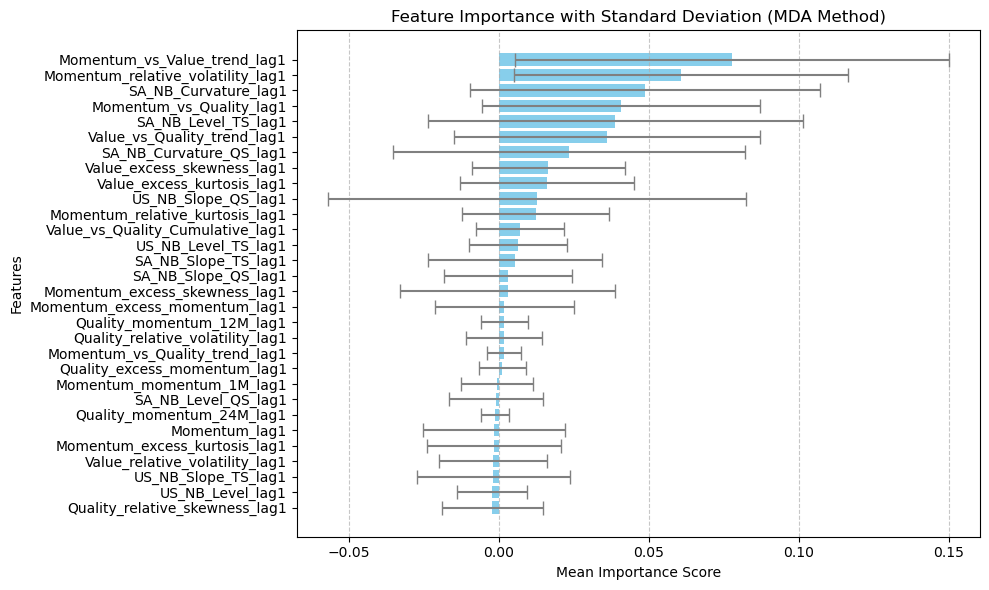

In [6]:
plot_feature_importance(importance_df, top_n=30)

In [7]:
    # Display results
print("Top 10 Most Important Features:")
print(importance_df.head(20))

Top 10 Most Important Features:
                                   mean_importance  std_importance
Momentum_vs_Value_trend_lag1              0.077647        0.072316
Momentum_relative_volatility_lag1         0.060672        0.055509
SA_NB_Curvature_lag1                      0.048708        0.058277
Momentum_vs_Quality_lag1                  0.040774        0.046306
SA_NB_Level_TS_lag1                       0.038828        0.062552
Value_vs_Quality_trend_lag1               0.036038        0.050920
SA_NB_Curvature_QS_lag1                   0.023423        0.058594
Value_excess_skewness_lag1                0.016468        0.025427
Value_excess_kurtosis_lag1                0.016015        0.029145
US_NB_Slope_QS_lag1                       0.012678        0.069741
Momentum_relative_kurtosis_lag1           0.012243        0.024495
Value_vs_Quality_Cumulative_lag1          0.007059        0.014681
US_NB_Level_TS_lag1                       0.006289        0.016401
SA_NB_Slope_TS_lag1           

In [8]:
# Select top features by mean importance
top_features = importance_df.head(50).index

# Cut down original dataset
X_top50 = X[top_features]

# (Optional) keep labels together
#data_top50 = pd.concat([X_top50, pd.Series(y, index=X.index, name='trend_bin')], axis=1)

# Save to CSV
X_top50.to_csv("top50_features.csv", index=True)

print("Saved reduced dataset with top 50 features to top50_features_dataset.csv")


Saved reduced dataset with top 50 features to top50_features_dataset.csv
